## Credit Card Fraud Detection (XGBoost)

- **Type:** Classification
- **Algorithm:** XGBoost
- **Dataset:** Credit Card Fraud Detection (stratified sample, 50,492 transactions, 492 fraud cases)
- **Goal:** Detect fraudulent credit card transactions from anonymized, PCA-transformed features
- **Key Techniques:** Severe Class Imbalance Handling (scale_pos_weight), Stratified Train/Test Split, Confusion Matrix, Cross-Validation
- **Result:** Accuracy 0.9983 | Precision 0.9355 | Recall 0.8878 | F1 0.9110 | CV Recall 0.8537

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
df = pd.read_csv("../data/creditcard_sample.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,66706.0,1.199490,0.197301,0.616923,0.554820,-0.526523,-0.785182,-0.036202,-0.070460,-0.224568,...,-0.191542,-0.597586,0.148051,0.529668,0.158453,0.064369,-0.033132,0.011166,3.59,0
1,118737.0,2.054939,-0.005134,-1.050691,0.401563,-0.047484,-1.112092,0.218426,-0.350042,0.430742,...,-0.275390,-0.616070,0.338719,0.006520,-0.288834,0.198696,-0.062744,-0.059034,1.29,0
2,67555.0,-0.943726,-0.366261,2.292128,-1.909816,-0.305247,1.903637,-0.998268,0.757791,0.170689,...,0.109482,0.651761,-0.502554,-1.659885,0.669679,-0.000532,0.228359,0.088451,2.00,0
3,6428.0,-0.960946,0.864361,1.286077,0.131434,0.630708,-0.746227,0.567456,-0.281288,0.965197,...,-0.375636,-0.589018,0.275299,-0.161066,-0.491036,-0.020583,0.150700,0.179427,5.36,0
4,159884.0,1.688499,0.142083,-2.975027,0.857739,0.752403,-1.699499,0.883376,-0.527584,-0.050348,...,0.021742,-0.179006,-0.069067,0.967166,0.029453,0.613583,-0.095408,0.044466,195.00,0


In [41]:
df.shape

(50492, 31)

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50492 entries, 0 to 50491
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    50492 non-null  float64
 1   V1      50492 non-null  float64
 2   V2      50492 non-null  float64
 3   V3      50492 non-null  float64
 4   V4      50492 non-null  float64
 5   V5      50492 non-null  float64
 6   V6      50492 non-null  float64
 7   V7      50492 non-null  float64
 8   V8      50492 non-null  float64
 9   V9      50492 non-null  float64
 10  V10     50492 non-null  float64
 11  V11     50492 non-null  float64
 12  V12     50492 non-null  float64
 13  V13     50492 non-null  float64
 14  V14     50492 non-null  float64
 15  V15     50492 non-null  float64
 16  V16     50492 non-null  float64
 17  V17     50492 non-null  float64
 18  V18     50492 non-null  float64
 19  V19     50492 non-null  float64
 20  V20     50492 non-null  float64
 21  V21     50492 non-null  float64
 22  V22     5

In [43]:
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
Time,50492.0,94841.311138,47493.217321,0.000000,54334.750000,84737.500000,139325.750000,172787.000000
V1,50492.0,-0.035635,2.084980,-46.855047,-0.928728,0.015215,1.312095,2.420346
V2,50492.0,0.025119,1.721289,-48.060856,-0.596533,0.075920,0.819162,22.057729
V3,50492.0,-0.057381,1.738835,-31.103685,-0.921974,0.167454,1.015725,4.101716
V4,50492.0,0.044276,1.486651,-5.519697,-0.826216,-0.002673,0.769941,13.129143
V5,50492.0,-0.012758,1.452318,-28.815577,-0.698951,-0.056135,0.621563,29.162172
V6,50492.0,-0.011760,1.333538,-20.869626,-0.775180,-0.278846,0.393863,21.190194
V7,50492.0,-0.051729,1.433441,-43.557242,-0.567930,0.036328,0.570005,26.249717
V8,50492.0,0.008859,1.328826,-50.420090,-0.204803,0.025071,0.331369,20.007208
V9,50492.0,-0.010958,1.144422,-13.434066,-0.647703,-0.050236,0.597968,10.370658


In [44]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [45]:
df['Class'].value_counts()

Class
0    50000
1      492
Name: count, dtype: int64

In [46]:
df['Class'].value_counts(normalize=True)

Class
0    0.990256
1    0.009744
Name: proportion, dtype: float64

In [47]:
X = df.drop(columns=['Class'])
y = df['Class']

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [49]:
print(y_train.mean())
print(y_test.mean())

0.00975416532567524
0.009703931082285375


In [50]:
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

scale = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(n_estimators=100, max_depth=5, scale_pos_weight=scale, random_state=42, eval_metric='logloss')

In [51]:
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1: {f1_score(y_test, y_pred_xgb):.4f}")

Accuracy: 0.9983
Precision: 0.9355
Recall: 0.8878
F1: 0.9110


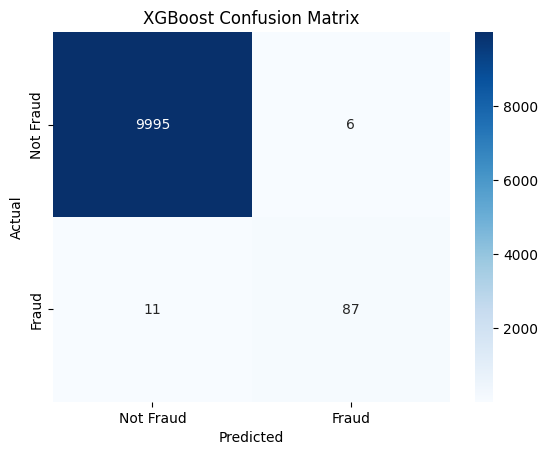

In [53]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score


cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.show()

In [60]:
scores_xgb = cross_val_score(xgb, X, y, cv=5, scoring='recall')
print(f"CV Recall scores: {scores_xgb}")
print(f"Mean: {scores_xgb.mean():.4f}, Std: {scores_xgb.std():.4f}")

CV Recall scores: [0.80808081 0.86868687 0.83673469 0.87755102 0.87755102]
Mean: 0.8537, Std: 0.0273
